# PósTech FIAP - IA para Devs (Turma 9IADT)
## Tech Challenge - Fase 1
**Sistema de suporte ao diagnóstico médico do câncer de mama**

---

| Aluno | RM |
|--------|------------------|
| Antonio Bazo | 372646 |
| Renato Mattos | 370975 |
| Vinicius Geisler | 373670 |
| Marcelo Costa | 371714 |
| Vinicius Blasque | 370746 |

---

**Objetivo:** Construir um modelo de análise de dados de exames para classificação de tumores como benignos ou malignos, servindo como ferramenta de apoio ao diagnóstico

**Dataset principal:** [Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

---


In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'pyproject.toml').exists():
    candidate = Path.cwd().resolve().parent
    if (candidate / 'pyproject.toml').exists():
        PROJECT_ROOT = candidate

os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

required_modules = ['matplotlib', 'numpy', 'pandas', 'seaborn', 'scipy', 'sklearn']
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing_modules:
    print(f'Missing notebook dependencies in this kernel: {missing_modules}')
    print(f'Installing project dependencies into: {sys.executable}')
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-e',
        str(PROJECT_ROOT),
    ])

print(f'Working directory: {PROJECT_ROOT}')
print(f'Python kernel: {sys.executable}')


Missing notebook dependencies in this kernel: ['matplotlib', 'numpy', 'pandas', 'seaborn', 'scipy', 'sklearn']
Installing project dependencies into: /usr/local/bin/python
Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///workspaces/9IADT-tech-challenge
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Working directory: /workspaces/9IADT-tech-challenge
Python kernel: /usr/local/bin/python


## 1. Setup e Dependências

Configuração do workspace e carregamento das bibliotecas necessárias para análise exploratória, engenharia de atributos e treinamento dos modelos de classificação.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# Algoritmos e Métricas
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Machine Learning - Engenharia e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Ambiente configurado.")

Ambiente configurado.


## 2. Ingestão e Carregamento dos Dados

Leitura da base de dados original e carregamento em DataFrame para inspeção inicial da estrutura, dimensões e integridade das informações.

In [3]:
# Carregamento do dataset
dataset = pd.read_csv("data/breast-cancer-wisconsin-diagnostic-data-set.csv")

# Exibição das dimensões do dataset
print(f"Dataset carregado com sucesso: {dataset.shape[0]} instâncias e {dataset.shape[1]} atributos.")

# Visualização das 5 primeiras linhas
dataset.head()

Dataset carregado com sucesso: 569 instâncias e 33 atributos.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Limpeza e Transformação Inicial dos Dados

Eliminação de atributos irrelevantes (identificadores e resíduos de carga) e mapeamento da variável alvo para terminologia clínica. O objetivo é garantir a integridade do conjunto de dados e a legibilidade das análises subsequentes.

In [4]:
# Remoção de colunas desnecessárias
dataset.drop(["Unnamed: 32", "id"], axis=1, inplace=True)

# Mapeamento de rótulos para suporte à interpretação clínica
dataset["diagnosis"] = dataset["diagnosis"].map({"M": "Maligno", "B": "Benigno"})

# Validações e Prova de Sanidade
print("--- RELATÓRIO DE LIMPEZA ---")
print(f"Valores nulos restantes: {dataset.isnull().sum().sum()}")
print(f"Novas dimensões (Linhas, Colunas): {dataset.shape}\n")

print("Distribuição da variável alvo:")
print(dataset["diagnosis"].value_counts())
print("\n" + "-" * 30 + "\n")

# O info() exibe um resumo técnico detalhado dos tipos de dados
dataset.info()

--- RELATÓRIO DE LIMPEZA ---
Valores nulos restantes: 0
Novas dimensões (Linhas, Colunas): (569, 31)

Distribuição da variável alvo:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_di

## 4. Resumo Estatístico dos Dados

Extração de métricas centrais e de dispersão (média, desvio padrão, quartis e amplitudes) das características dos tumores. A visualização transposta facilita a inspeção rápida de escalas, permitindo identificar a variação de magnitude entre os atributos.

In [5]:
# Geração de estatísticas descritivas com transposição e arredondamento para legibilidade
dataset.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


## 5. Análise de Outliers (Pontos Fora da Curva)

Aplicação do método IQR (Interquartile Range) para identificação de valores atípicos nas dimensões dos tumores. Esta análise é essencial para quantificar o volume de dados extremos que podem impactar a variância global e influenciar o comportamento dos algoritmos sensíveis a escalas.

In [6]:
# Selecionamos apenas as colunas de números para o cálculo
colunas_numericas = dataset.select_dtypes(include=["float64"])

# Cálculo do Intervalo Interquartil (IQR)
Q1 = colunas_numericas.quantile(0.25)
Q3 = colunas_numericas.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites (o padrão é 1.5)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contando quantos outliers existem em cada coluna
outliers = ((colunas_numericas < limite_inferior) | (colunas_numericas > limite_superior)).sum()

print("Resumo de Outliers encontrados por coluna:")
print(outliers[outliers > 0].sort_values(ascending=False))

Resumo de Outliers encontrados por coluna:
area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
symmetry_worst             23
concavity_se               22
texture_se                 20
concave points_se          19
concavity_mean             18
radius_worst               17
compactness_worst          16
compactness_mean           16
fractal_dimension_mean     15
perimeter_worst            15
symmetry_mean              15
radius_mean                14
perimeter_mean             13
concavity_worst            12
concave points_mean        10
smoothness_worst            7
texture_mean                7
smoothness_mean             6
texture_worst               5
dtype: int64


**Decisão Técnica: Retenção de Outliers**
A detecção de valores atípicos (ex: 65 registros em area_se) **não resultará na exclusão** manual desses dados. No domínio da oncologia, extremos estatísticos frequentemente representam a variabilidade biológica de tumores mais agressivos ou casos críticos.

Como o objetivo do modelo é priorizar o Recall (Sensibilidade), a manutenção desses registros é estratégica. O algoritmo deve ser capaz de aprender padrões de variabilidade extrema para minimizar falhas de diagnóstico (falsos negativos), garantindo maior segurança clínica na identificação de casos malignos.

Por isso decidimos **não removê-los**.


### Análise Exploratória Visual (EDA)

Avaliação da distribuição das classes para verificação de balanceamento do dataset e análise de densidade de atributos-chave. O objetivo é identificar padrões de separação e o nível de sobreposição entre diagnósticos benignos e malignos em variáveis críticas.

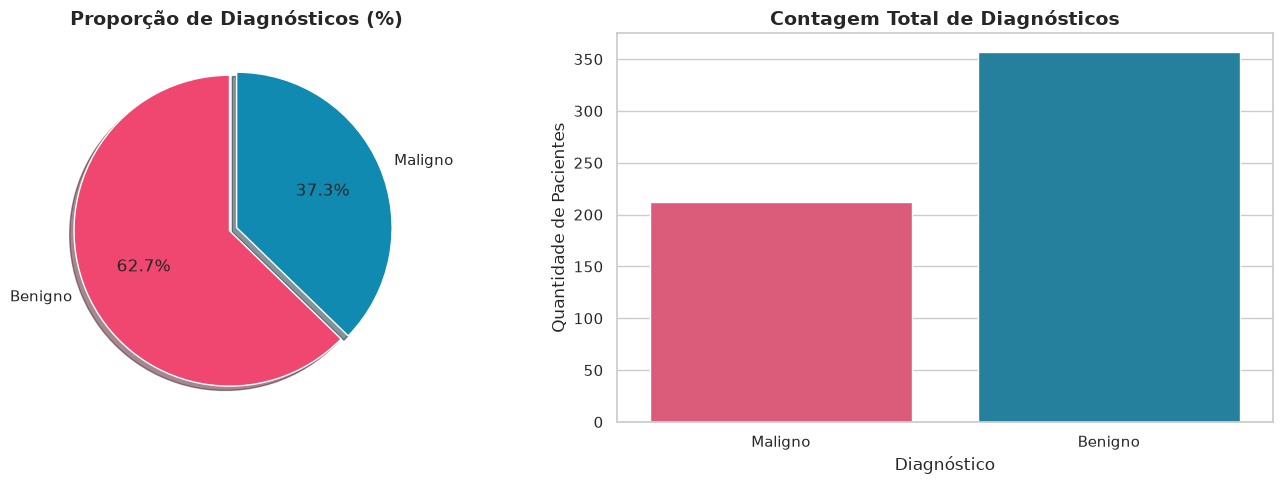

In [7]:
# Configuração visual elegante
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(14, 5))

# GRÁFICO REDONDO (mostra a Porcentagem)
plt.subplot(1, 2, 1)
contagem = dataset["diagnosis"].value_counts()
plt.pie(
    contagem,
    labels=contagem.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ef476f", "#118ab2"],
    explode=(0.05, 0),
    shadow=True,
)
plt.title("Proporção de Diagnósticos (%)", fontsize=14, fontweight="bold")

# GRÁFICO BARRAS (mostra a Quantidade Absoluta)
plt.subplot(1, 2, 2)
sns.countplot(
    data=dataset, x="diagnosis", hue="diagnosis", palette={"Maligno": "#ef476f", "Benigno": "#118ab2"}, legend=False
)
plt.title("Contagem Total de Diagnósticos", fontsize=14, fontweight="bold")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade de Pacientes")

plt.tight_layout()
plt.show()

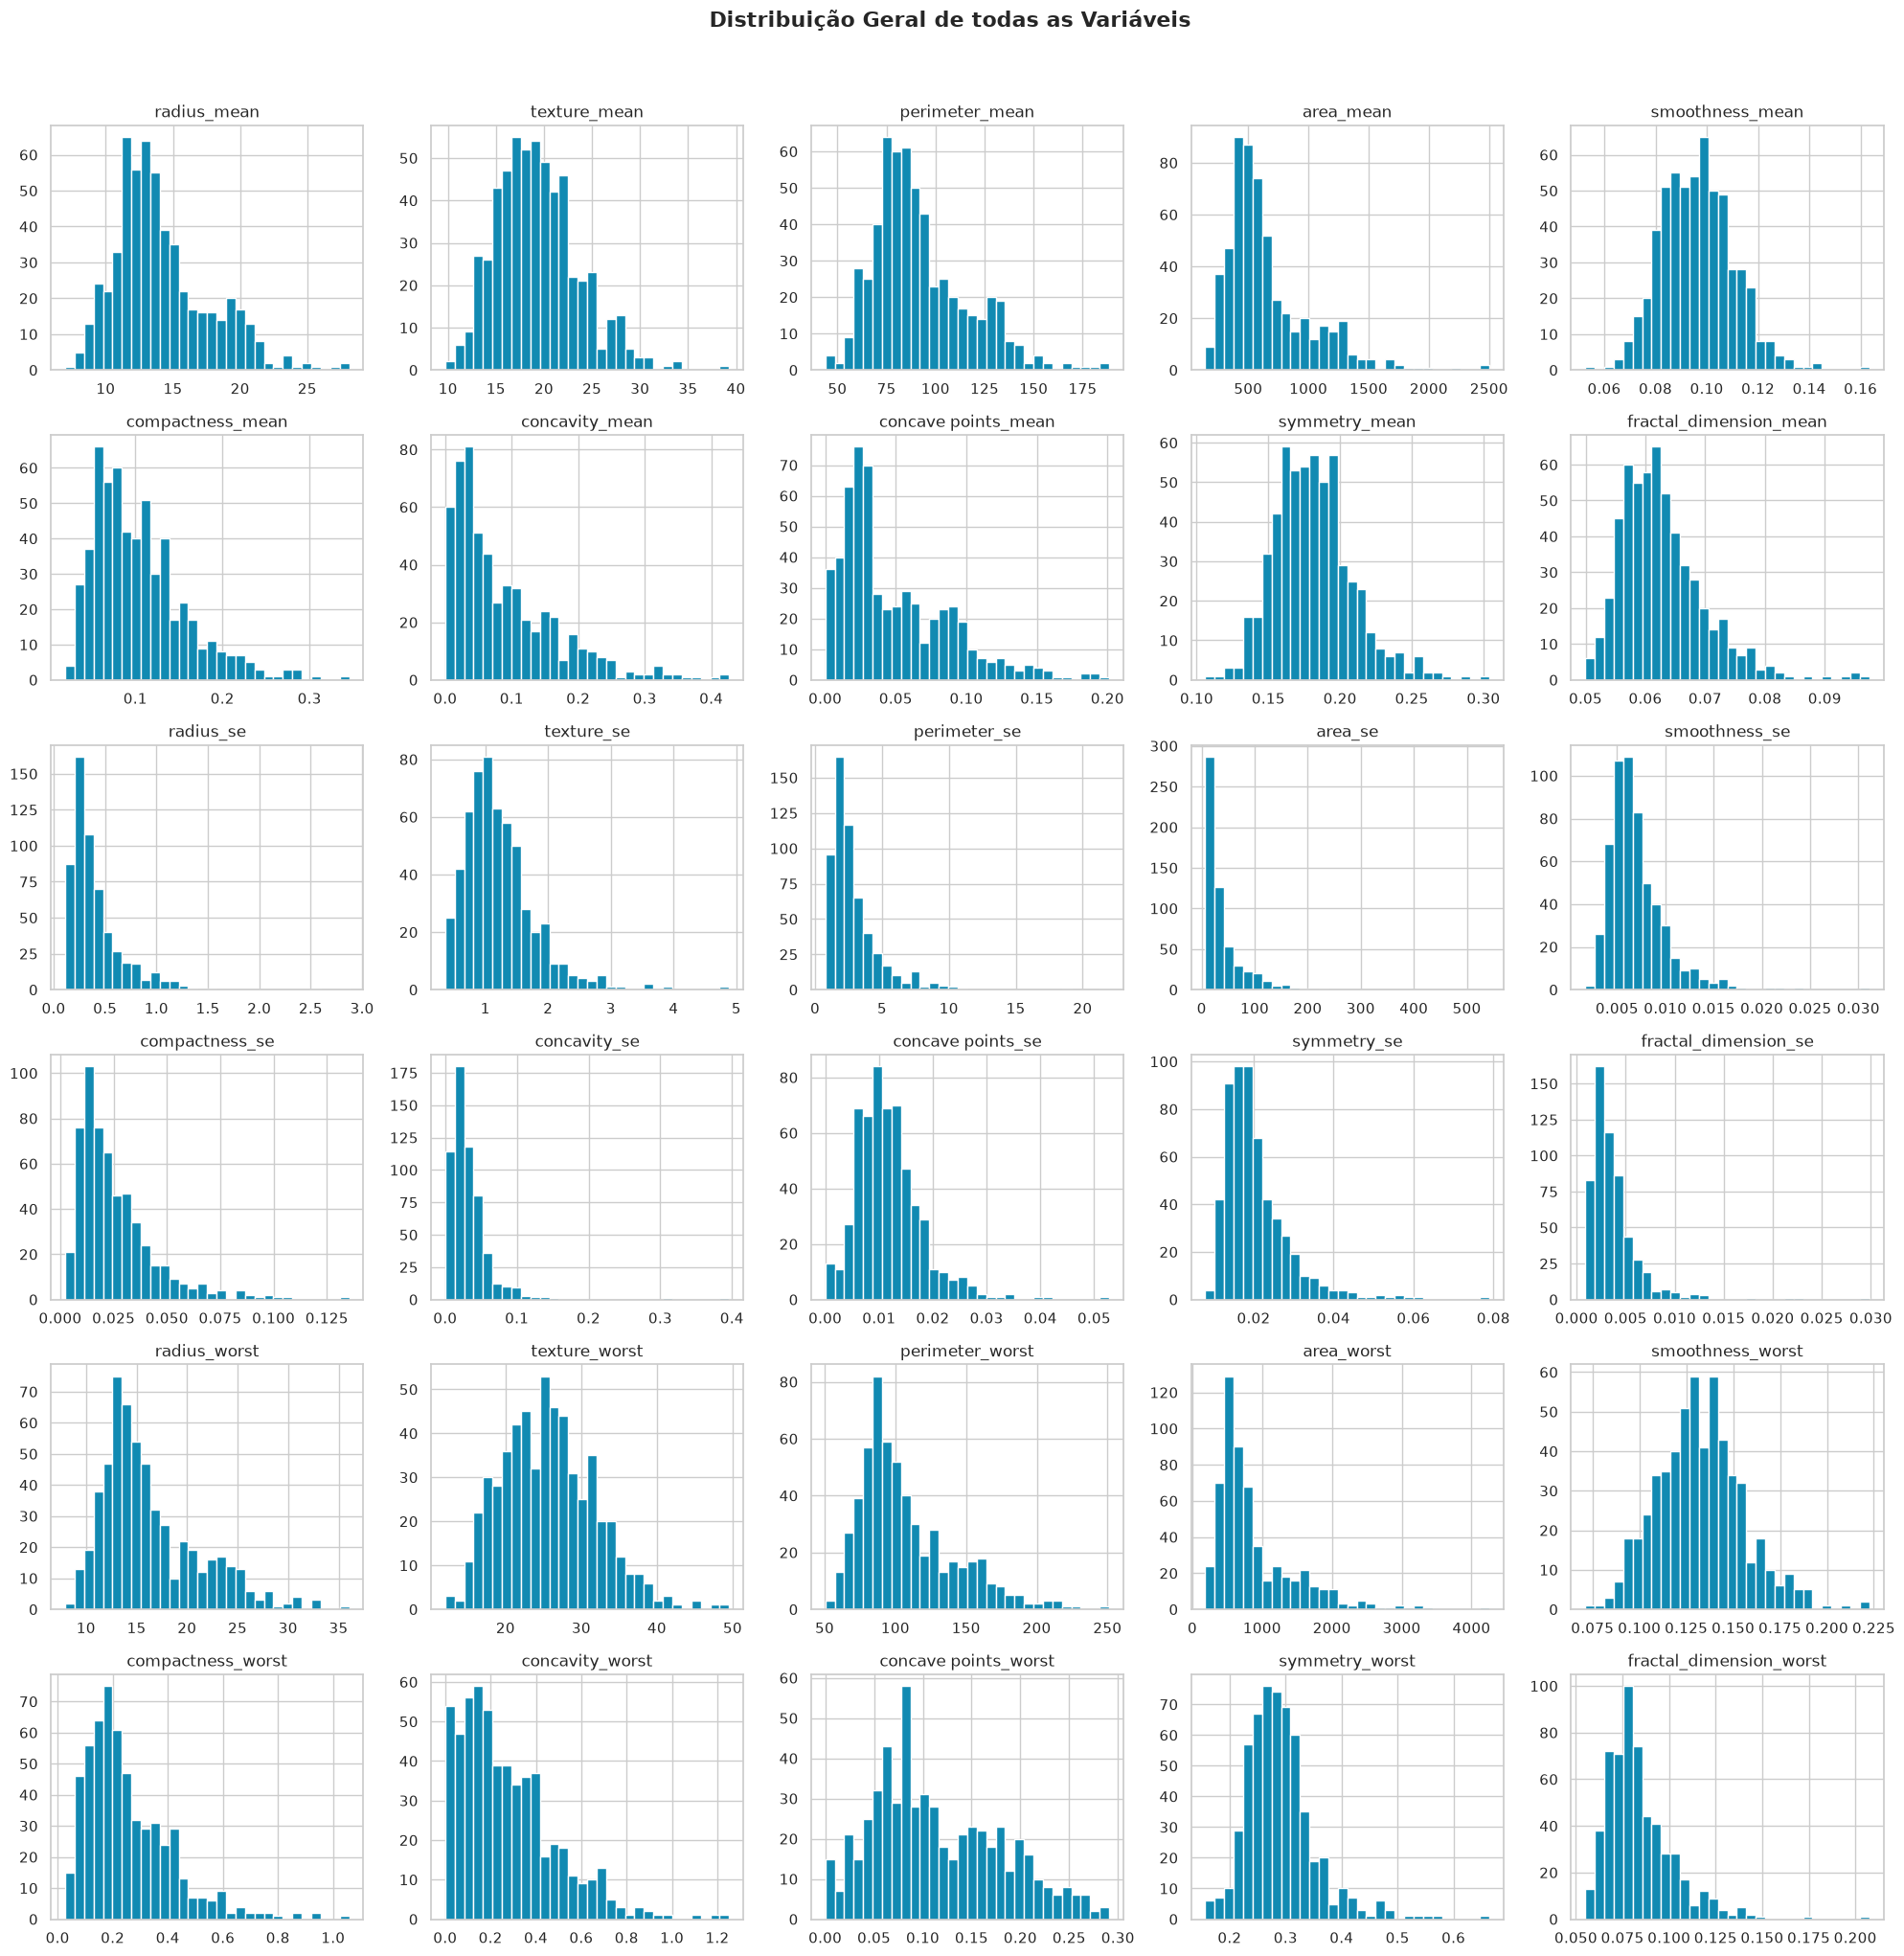

In [8]:
# Histograma de todas as variáveis para visão geral
dataset.hist(bins=30, figsize=(20, 20), color="#118ab2", edgecolor="white")
plt.suptitle("Distribuição Geral de todas as Variáveis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Particionamento entre Treino e Teste

Segregação do conjunto de dados em subconjuntos de treinamento e teste para validação da capacidade de generalização. O particionamento é essencial para garantir que a performance final seja mensurada em dados não observados durante o ajuste do modelo, mitigando riscos de overfitting.

In [9]:
# Separação de Features (X) e Target (y)
X = dataset.drop(columns=["diagnosis"])
y = dataset["diagnosis"]

# Divisão dos dados (80/20) com estratificação para preservar a proporção de classes
# Usamos o random_state=42 para garantir que o resultado seja sempre o mesmo ao rodar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verificação das dimensões e proporcao de classes
print("Separação concluída com sucesso:")
print(f"Amostras de Treino: {X_train.shape[0]} registros")
print(f"Amostras de Teste: {X_test.shape[0]} registros")
print(f"Total de atributos (Features): {X_train.shape[1]}")
print(f"Proporção Maligno no treino: {(y_train == 'Maligno').mean():.2%}")
print(f"Proporção Maligno no teste:  {(y_test == 'Maligno').mean():.2%}")

Separação concluída com sucesso:
Amostras de Treino: 455 registros
Amostras de Teste: 114 registros
Total de atributos (Features): 30
Proporção Maligno no treino: 37.36%
Proporção Maligno no teste:  36.84%


## 7. Padronização de Atributos (Feature Scaling)

Considerando a disparidade de escalas entre as variáveis (identificada na análise descritiva) e a sensibilidade do PCA e dos classificadores a essas magnitudes, aplicamos a padronização via StandardScaler.

**Critério Técnico:** O ajuste (fit) é realizado exclusivamente no conjunto de treinamento para mitigar o risco de Data Leakage (vazamento de dados), assegurando que informações do teste não influenciem os parâmetros da escala.

In [10]:
# Instanciamos o "padronizador"
scaler = StandardScaler()

# Ajuste e transformação do treino; apenas transformação do teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversão para DataFrame para preservação dos nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificação visual
X_train_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
3,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
4,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


## 8. Análise de Multicolinearidade (Matriz de Correlação)

Cálculo da matriz de correlação aplicado ao conjunto de treinamento para identificação de redundâncias entre os atributos. Este diagnóstico fornece o subsídio estatístico para a aplicação do PCA, permitindo simplificar o espaço de características ao mitigar a multicolinearidade sem comprometer a variância explicada.

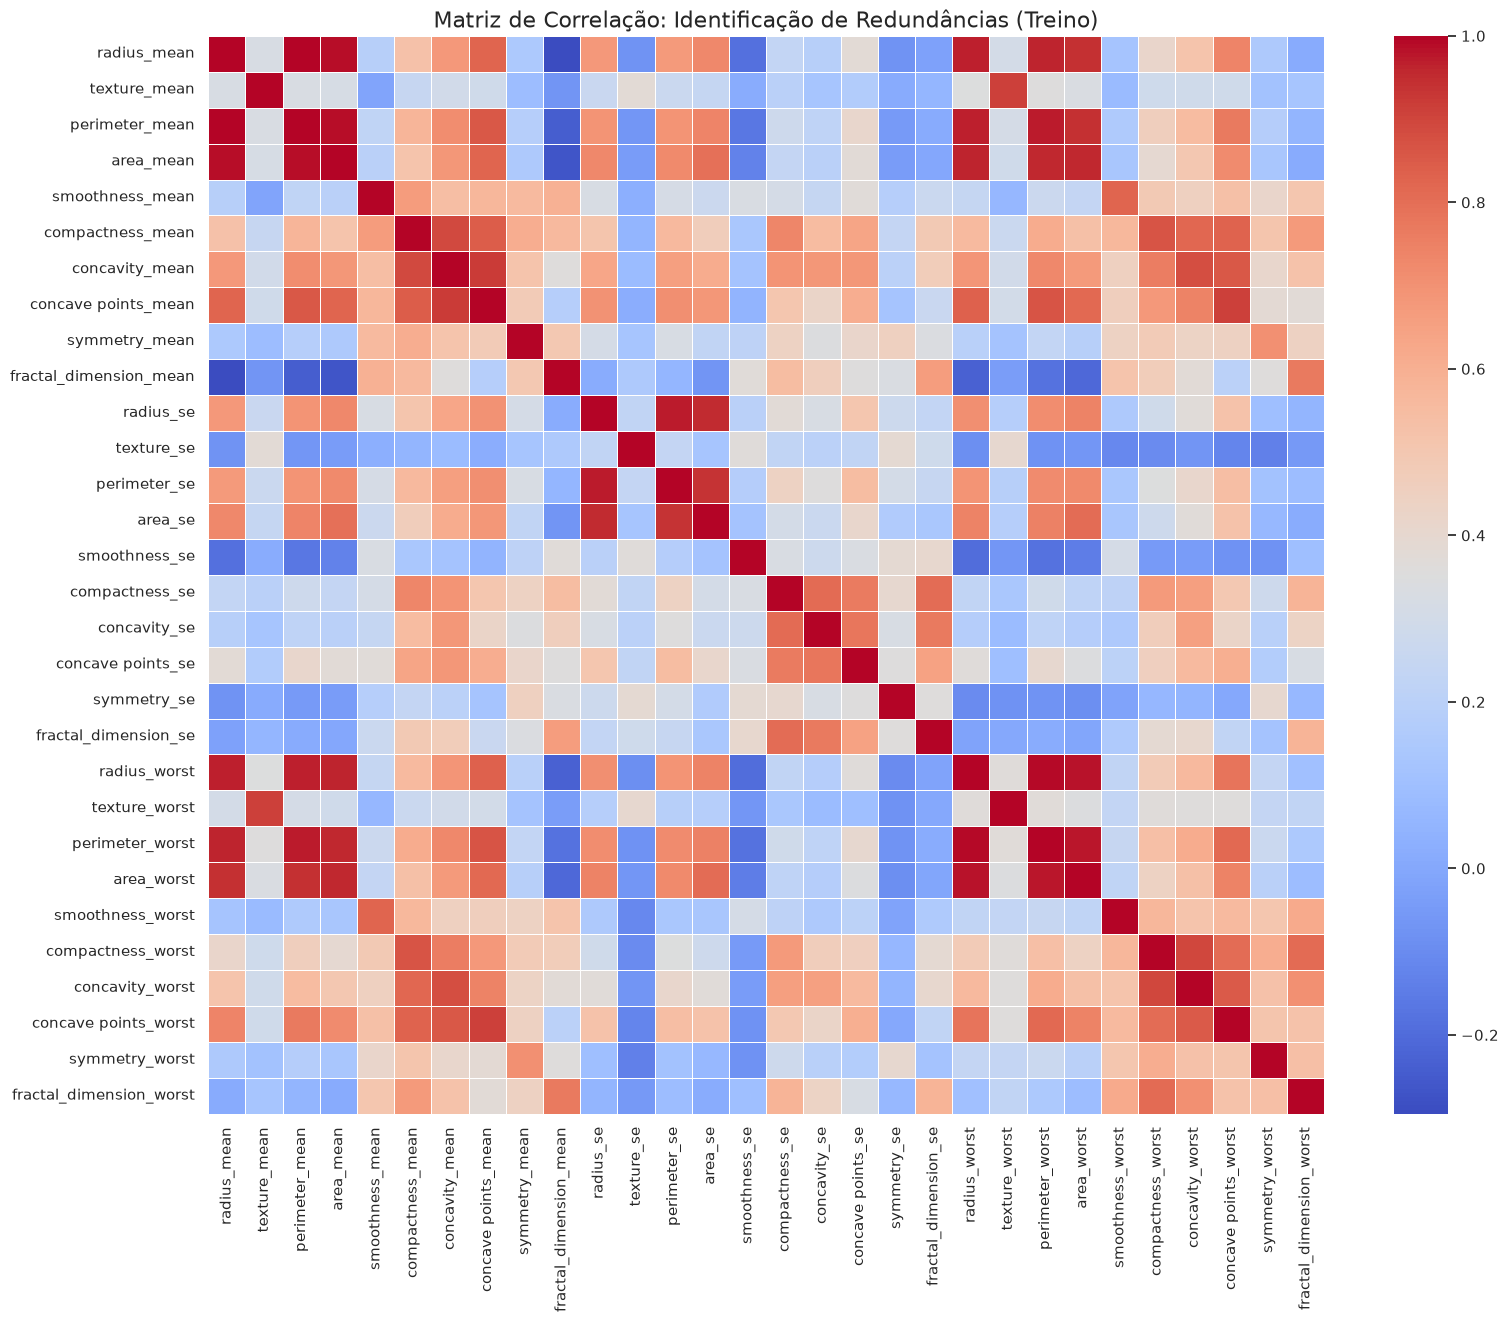

In [11]:
# Cálculo da matriz de correlação (Pearson)
matriz_correlacao = X_train_scaled.corr()

# Configuração da visualização via Mapa de Calor (Heatmap)
plt.figure(figsize=(18, 14))

# Visualização das correlações: tons de vermelho indicam alta colinearidade
sns.heatmap(matriz_correlacao, annot=False, cmap="coolwarm", linewidths=0.5)

plt.title("Matriz de Correlação: Identificação de Redundâncias (Treino)", fontsize=16)
plt.show()

## 9. Redução de Dimensionalidade (PCA)

Aplicação de Principal Component Analysis (PCA) para compressão do espaço de características, visando mitigar a redundância identificada na análise de colinearidade. O objetivo é reduzir a complexidade dimensional e o custo computacional do modelo, retendo 95% da variância total do conjunto de dados original.

--- RELATÓRIO DO PCA ---
Colunas originais: 30
Colunas após PCA: 10
Informação preservada: 95.21%



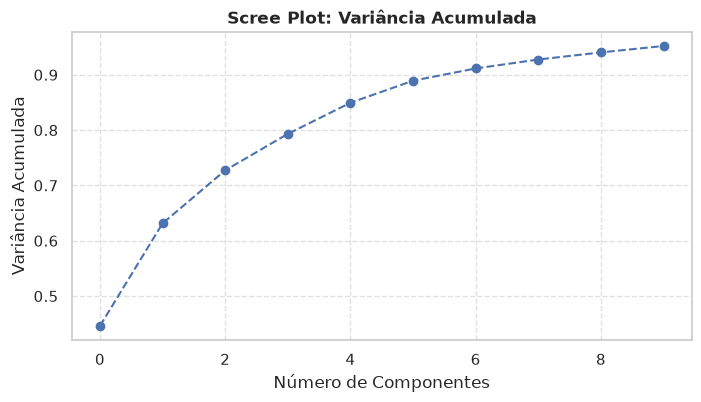

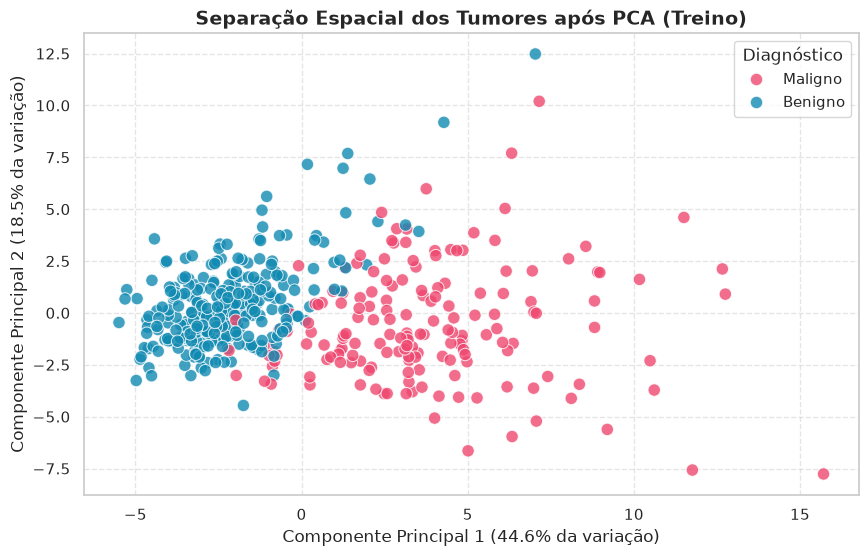

--- ANÁLISE DE NORMALIDADE (SHAPIRO-WILK) ---
PC1: p-value = 0.0000 -> Não apresenta Normalidade
PC2: p-value = 0.0000 -> Não apresenta Normalidade
PC3: p-value = 0.0000 -> Não apresenta Normalidade
PC4: p-value = 0.0001 -> Não apresenta Normalidade
PC5: p-value = 0.0000 -> Não apresenta Normalidade


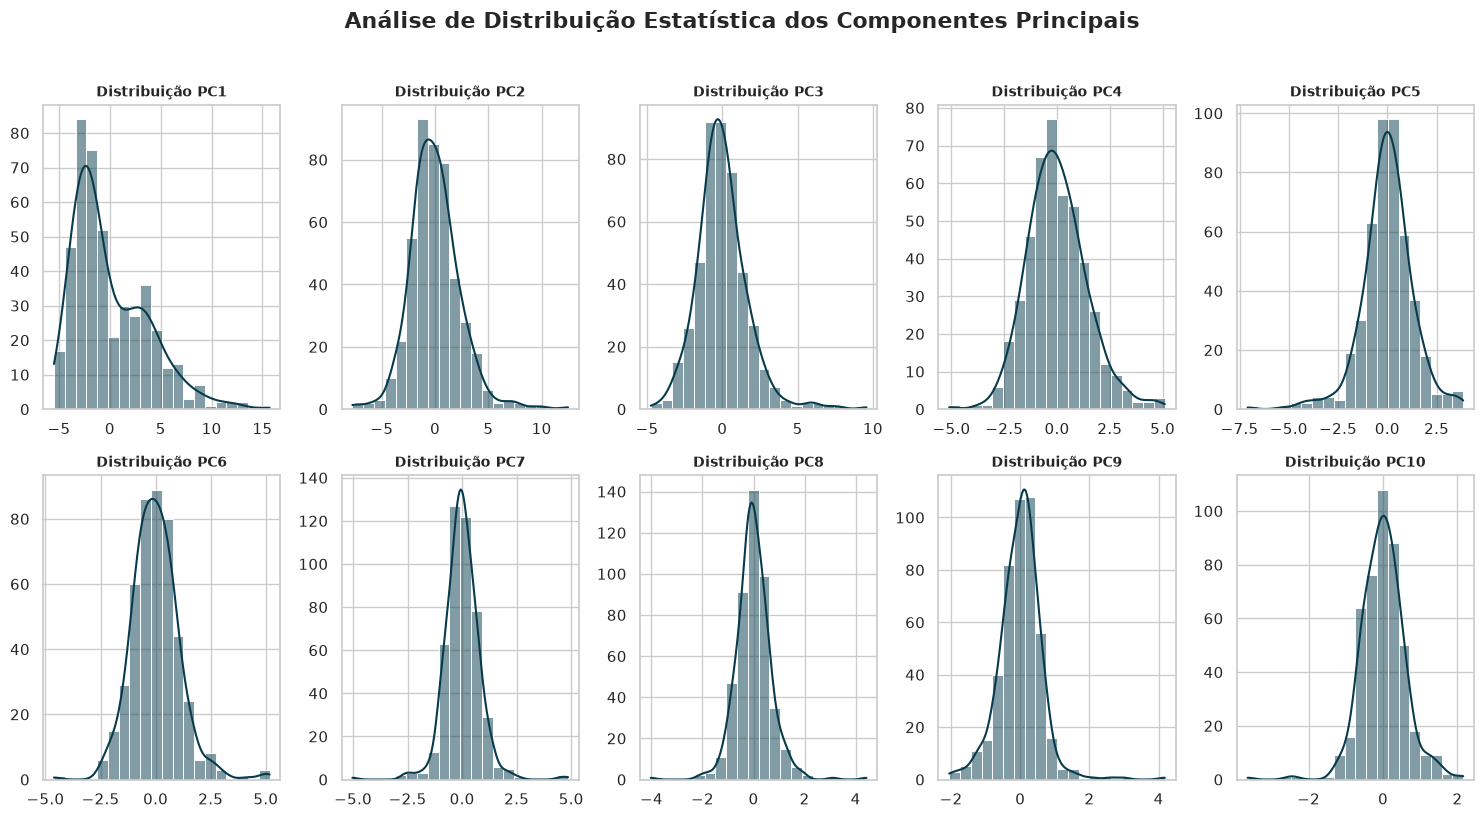


Tabela final criada com 10 componentes principais.


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Diagnóstico
0,-0.875937,-2.571309,-0.548511,1.635793,-0.262836,0.109819,0.506414,-0.214460,-0.109384,0.416695,Maligno
1,-2.505128,0.192453,-0.404965,-2.447875,0.600618,0.007704,-1.094288,0.073162,0.554590,0.155714,Benigno
2,-1.354117,0.417851,2.545009,1.218872,-1.766641,0.708774,0.766716,-0.053032,-0.437219,0.186073,Benigno
3,4.854091,3.017576,-1.626587,0.702197,-2.814424,-0.375296,-0.473987,0.060816,0.179790,-0.563521,Maligno
4,2.926225,-1.866546,2.486468,-0.104045,0.181489,-0.974601,-0.773459,-0.177466,-0.220212,-0.343456,Maligno


In [12]:
# --- Aplicação do PCA ---
# Configuração para preservação de 95% da informação
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Diagnóstico de redução
print("--- RELATÓRIO DO PCA ---")
print(f"Colunas originais: {X_train_scaled.shape[1]}")
print(f"Colunas após PCA: {X_train_pca.shape[1]}")
print(f"Informação preservada: {sum(pca.explained_variance_ratio_):.2%}\n")

# --- Prova de Variância (Scree Plot) ---
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o", linestyle="--")
plt.title("Scree Plot: Variância Acumulada", fontsize=12, fontweight="bold")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Acumulada")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Verificação visual da separação das classes nos dois primeiros componentes
pca_df_vis = pd.DataFrame(data=X_train_pca[:, :2], columns=["PC1", "PC2"])
pca_df_vis["Diagnóstico"] = y_train.values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df_vis,
    x="PC1",
    y="PC2",
    hue="Diagnóstico",
    palette={"Maligno": "#ef476f", "Benigno": "#118ab2"},
    alpha=0.8,
    s=80,
    edgecolor="white",
)

plt.title("Separação Espacial dos Tumores após PCA (Treino)", fontsize=14, fontweight="bold")
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} da variação)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} da variação)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Diagnóstico de Normalidade (Shapiro-Wilk) ---
num_de_pca = X_train_pca.shape[1]
nomes_colunas = [f"PC{i}" for i in range(1, num_de_pca + 1)]
pca_df_temp = pd.DataFrame(data=X_train_pca, columns=nomes_colunas)

print("--- ANÁLISE DE NORMALIDADE (SHAPIRO-WILK) ---")
# Testamos os primeiros componentes (que carregam mais informação)
for column in pca_df_temp.columns[:5]:
    stat, p_value = shapiro(pca_df_temp[column])
    status = "Próxima da Normalidade" if p_value > 0.05 else "Não apresenta Normalidade"
    print(f"{column}: p-value = {p_value:.4f} -> {status}")

# --- Distribuição Estatística dos Componentes ---
plt.figure(figsize=(15, 8))
for i, col in enumerate(pca_df_temp.columns[:10]):
    plt.subplot(2, 5, i + 1)
    sns.histplot(pca_df_temp[col], bins=20, kde=True, color="#073b4c")
    plt.title(f"Distribuição {col}", fontsize=10, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Análise de Distribuição Estatística dos Componentes Principais", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Estruturação do Dataset Final ---
pca_df_final = pd.DataFrame(data=X_train_pca, columns=nomes_colunas)
pca_df_final["Diagnóstico"] = y_train.values

print(f"\nTabela final criada com {num_de_pca} componentes principais.")
pca_df_final.head()

## 10. Avaliação Comparativa de Modelos (Benchmarking)

Execução de testes entre diferentes algoritmos para validar a eficácia da redução de dimensionalidade. Além da Acurácia, priorizamos o Recall, garantindo que a comparação reflita a capacidade do modelo em mitigar falsos negativos no diagnóstico.

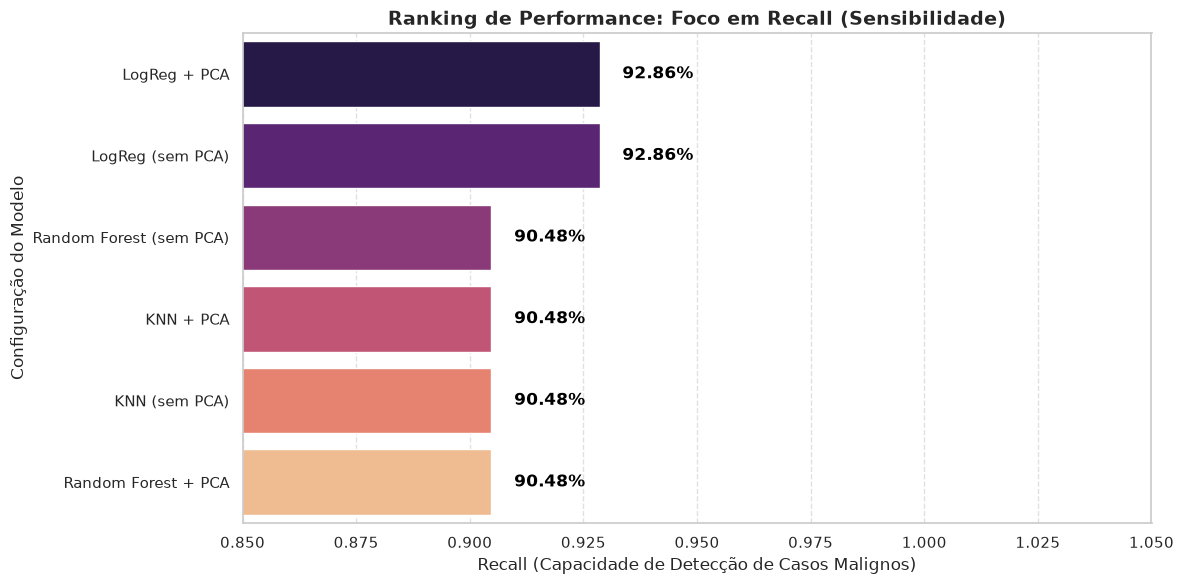

           Configuração  Acurácia  Recall (Maligno)
           LogReg + PCA  0.973684          0.928571
       LogReg (sem PCA)  0.964912          0.928571
Random Forest (sem PCA)  0.964912          0.904762
              KNN + PCA  0.956140          0.904762
          KNN (sem PCA)  0.956140          0.904762
    Random Forest + PCA  0.947368          0.904762


In [13]:
# Importação da métrica adicional
from sklearn.metrics import recall_score

# --- Configuração dos pipelines a comparar (com e sem PCA, em diferentes algoritmos) ---
modelos = {
    "LogReg + PCA": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", LogisticRegression(max_iter=5000, random_state=42)),
        ]
    ),
    "KNN + PCA": Pipeline(
        [("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)), ("model", KNeighborsClassifier(n_neighbors=5))]
    ),
    "Random Forest + PCA": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
        ]
    ),
    "LogReg (sem PCA)": Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=42))]
    ),
    "KNN (sem PCA)": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest (sem PCA)": Pipeline(
        [("scaler", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, random_state=42))]
    ),
}

# --- Ciclo de Treinamento e Avaliação Multimétrica ---
resultados = []

for nome, pipeline in modelos.items():
    # Treinamento via Pipeline
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Cálculo das métricas (foco em 'Maligno' para o Recall)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label="Maligno")

    resultados.append({"Configuração": nome, "Acurácia": acc, "Recall (Maligno)": rec})

# Consolidação do Ranking (Ordenado por Recall, depois Acurácia)
comparacao_modelos = pd.DataFrame(resultados).sort_values(by=["Recall (Maligno)", "Acurácia"], ascending=False)

# --- Visualização de Performance (Recall) ---
plt.figure(figsize=(12, 6))
grafico = sns.barplot(
    data=comparacao_modelos, x="Recall (Maligno)", y="Configuração", hue="Configuração", palette="magma", legend=False
)

# Inserção de rótulos de Recall nas barras
for i, v in enumerate(comparacao_modelos["Recall (Maligno)"]):
    grafico.text(v + 0.005, i, f"{v:.2%}", color="black", va="center", fontweight="bold")

plt.title("Ranking de Performance: Foco em Recall (Sensibilidade)", fontsize=14, fontweight="bold")
plt.xlabel("Recall (Capacidade de Detecção de Casos Malignos)")
plt.ylabel("Configuração do Modelo")
plt.xlim(0.85, 1.05)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Resumo tabular detalhado
print(comparacao_modelos.to_string(index=False))

## 11. Seleção e Avaliação do Modelo Final

**Justificativa da Escolha**
Após o benchmarking, observamos que a estratégia de redução de dimensionalidade (PCA) preservou a capacidade preditiva dos algoritmos. O modelo de Regressão Logística com PCA foi selecionado por apresentar o melhor equilíbrio entre Recall (Sensibilidade) e simplicidade.

No contexto oncológico, priorizar o Recall garante que o sistema seja eficaz em identificar a classe maligna, reduzindo drasticamente o risco de falsos negativos. Além disso, a Regressão Logística oferece alta interpretabilidade estatística, facilitando a auditoria dos resultados pelo corpo médico.

--- AVALIAÇÃO FINAL DO MODELO ---
Acurácia Global: 97.37%
Recall (Sensibilidade para Maligno): 92.86%

Relatório de Classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



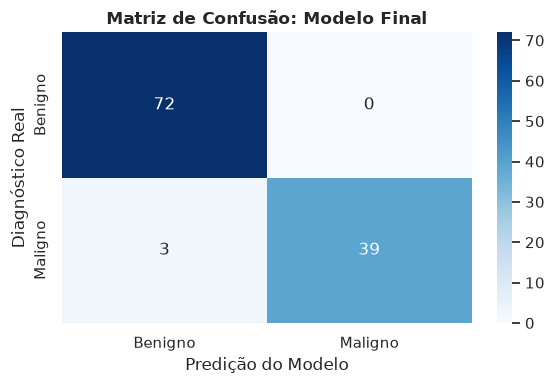

In [14]:
# Importação da métrica de recall para a validação final
from sklearn.metrics import recall_score

# --- Configuração do Modelo Final ---
modelo_final = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=num_de_pca)),
        ("model", LogisticRegression(max_iter=5000, random_state=42)),
    ]
)

# Treinamento consolidado
modelo_final.fit(X_train, y_train)

# Predição nos dados de teste (dados nunca vistos pelo modelo)
y_pred_final = modelo_final.predict(X_test)

# --- Relatório de Desempenho Clínico ---
print("--- AVALIAÇÃO FINAL DO MODELO ---")
print(f"Acurácia Global: {accuracy_score(y_test, y_pred_final):.2%}")
print(f"Recall (Sensibilidade para Maligno): {recall_score(y_test, y_pred_final, pos_label='Maligno'):.2%}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_final, target_names=["Benigno", "Maligno"]))

# --- Matriz de Confusão ---
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_final),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
)

plt.title("Matriz de Confusão: Modelo Final", fontweight="bold")
plt.xlabel("Predição do Modelo")
plt.ylabel("Diagnóstico Real")
plt.tight_layout()
plt.show()

## 12. Visão Computacional com CNN (Extra)

Aplicação complementar de *transfer learning* sobre o MobileNetV2 (pré-treinado no ImageNet) para classificação de mamografias, com explicabilidade via Grad-CAM.

In [15]:
# Bibliotecas adicionais para visão computacional e deep learning
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silencia INFO/WARNING do TF C++
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # silencia avisos de oneDNN
import tensorflow as tf

tf.get_logger().setLevel("ERROR")

# Reprodutibilidade: alinha com o padrão random_state=42 da parte tabular
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
import cv2
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuração de diretórios e geração de dataset sintético para demonstração
BASE_DIR = "data/images/breast_cancer"
TRAIN_DIR, VAL_DIR, TEST_DIR = [os.path.join(BASE_DIR, s) for s in ["train", "val", "test"]]
IMG_SIZE = (224, 224)
bp = os.path.join(TRAIN_DIR, "benign")
if not os.path.exists(bp) or len([f for f in os.listdir(bp) if f.endswith(".png")]) == 0:
    print("Gerando dataset sintético de mamografias para demonstração...")
    for split in ["train", "val", "test"]:
        for classe in ["benign", "malignant"]:
            dp = os.path.join(BASE_DIR, split, classe)
            os.makedirs(dp, exist_ok=True)
            for j in range({"train": 80, "val": 15, "test": 15}[split]):
                img = np.random.randint(20, 80, (224, 224, 3), dtype=np.uint8)
                cx, cy = np.random.randint(60, 164, 2)
                if classe == "malignant":
                    cv2.circle(img, (cx, cy), np.random.randint(20, 45), (180, 180, 180), -1)
                    for _ in range(8):
                        cv2.circle(
                            img,
                            (cx + np.random.randint(-25, 25), cy + np.random.randint(-25, 25)),
                            np.random.randint(5, 15),
                            (160, 160, 160),
                            -1,
                        )
                else:
                    cv2.circle(img, (cx, cy), np.random.randint(10, 25), (130, 130, 130), -1)
                cv2.imwrite(os.path.join(dp, f"{classe}_{j:04d}.png"), img)
    print("Pronto!")

# Augmentation no conjunto de treino e padronizacao no validacao/teste
train_dg = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)
val_dg = ImageDataGenerator(rescale=1.0 / 255)
train_gen = train_dg.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=32, class_mode="binary", shuffle=True
)
val_gen = val_dg.flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=32, class_mode="binary", shuffle=False)
test_gen = val_dg.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=32, class_mode="binary", shuffle=False)
print(f"Classes: {train_gen.class_indices} | Treino: {train_gen.samples} | Teste: {test_gen.samples}")

Found 100 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Classes: {'benign': 0, 'malignant': 1} | Treino: 100 | Teste: 20


**Critério Técnico:** *backbone* congelado para evitar retreino de milhões de parâmetros; ajuste restrito ao bloco denso (GAP + Dense + Dropout + Sigmoid). `EarlyStopping` e `ReduceLROnPlateau` controlam a convergência.

Epoch 1/15
4/4 - 3s - 793ms/step - accuracy: 0.7200 - loss: 0.6469 - val_accuracy: 0.9500 - val_loss: 0.3110 - learning_rate: 0.0010
Epoch 2/15
4/4 - 1s - 288ms/step - accuracy: 0.8800 - loss: 0.2782 - val_accuracy: 1.0000 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 3/15
4/4 - 2s - 498ms/step - accuracy: 0.9700 - loss: 0.1288 - val_accuracy: 1.0000 - val_loss: 0.1962 - learning_rate: 0.0010
Epoch 4/15
4/4 - 2s - 566ms/step - accuracy: 0.9800 - loss: 0.1037 - val_accuracy: 1.0000 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 5/15
4/4 - 3s - 633ms/step - accuracy: 0.9700 - loss: 0.1095 - val_accuracy: 1.0000 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 6/15
4/4 - 3s - 626ms/step - accuracy: 0.9900 - loss: 0.0480 - val_accuracy: 1.0000 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 7/15
4/4 - 1s - 365ms/step - accuracy: 0.9900 - loss: 0.0658 - val_accuracy: 1.0000 - val_loss: 0.1067 - learning_rate: 0.0010
Epoch 8/15
4/4 - 1s - 343ms/step - accuracy: 1.0000 - loss: 0.0217 - 

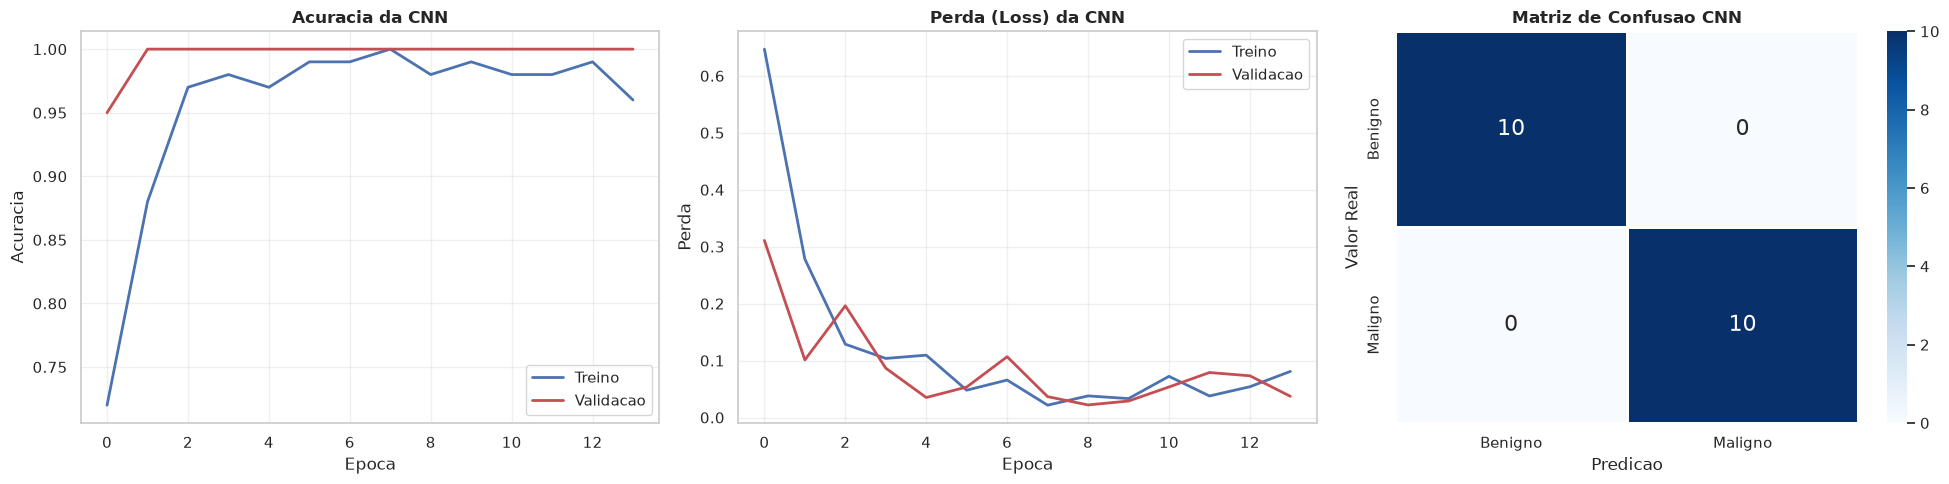

Acuracia CNN no teste: 1.0000


In [16]:
# Construcao do modelo: backbone congelado + cabeca densa treinavel
base_m = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_m.trainable = False
x = base_m.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
out_cnn = layers.Dense(1, activation="sigmoid")(x)
model_cnn = keras.Model(inputs=base_m.input, outputs=out_cnn)
model_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

cbs = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=0),
]
hist = model_cnn.fit(train_gen, epochs=15, validation_data=val_gen, callbacks=cbs, verbose=2)

# Avaliação no conjunto de teste: curvas de treino e matriz de confusao
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(hist.history["accuracy"], "b-", lw=2, label="Treino")
axes[0].plot(hist.history["val_accuracy"], "r-", lw=2, label="Validacao")
axes[0].set_title("Acuracia da CNN", fontweight="bold")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Acuracia")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(hist.history["loss"], "b-", lw=2, label="Treino")
axes[1].plot(hist.history["val_loss"], "r-", lw=2, label="Validacao")
axes[1].set_title("Perda (Loss) da CNN", fontweight="bold")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Perda")
axes[1].legend()
axes[1].grid(alpha=0.3)

test_gen.reset()
y_cnn_prob = model_cnn.predict(test_gen, verbose=0)
y_cnn_pred = (y_cnn_prob > 0.5).astype(int).flatten()
y_cnn_true = test_gen.classes
cm_cnn = confusion_matrix(y_cnn_true, y_cnn_pred)
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2],
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
    linewidths=1,
    annot_kws={"size": 16},
)
axes[2].set_title("Matriz de Confusao CNN", fontweight="bold")
axes[2].set_ylabel("Valor Real")
axes[2].set_xlabel("Predição")
plt.tight_layout()
plt.show()
print(f"Acuracia CNN no teste: {accuracy_score(y_cnn_true, y_cnn_pred):.4f}")

### Mapeamento de Atenção via Grad-CAM

Projeta sobre a imagem original as regiões da última camada convolucional (`Conv_1`) que mais contribuíram para a predição, permitindo auditoria visual: o modelo focou na massa tumoral ou em artefato?

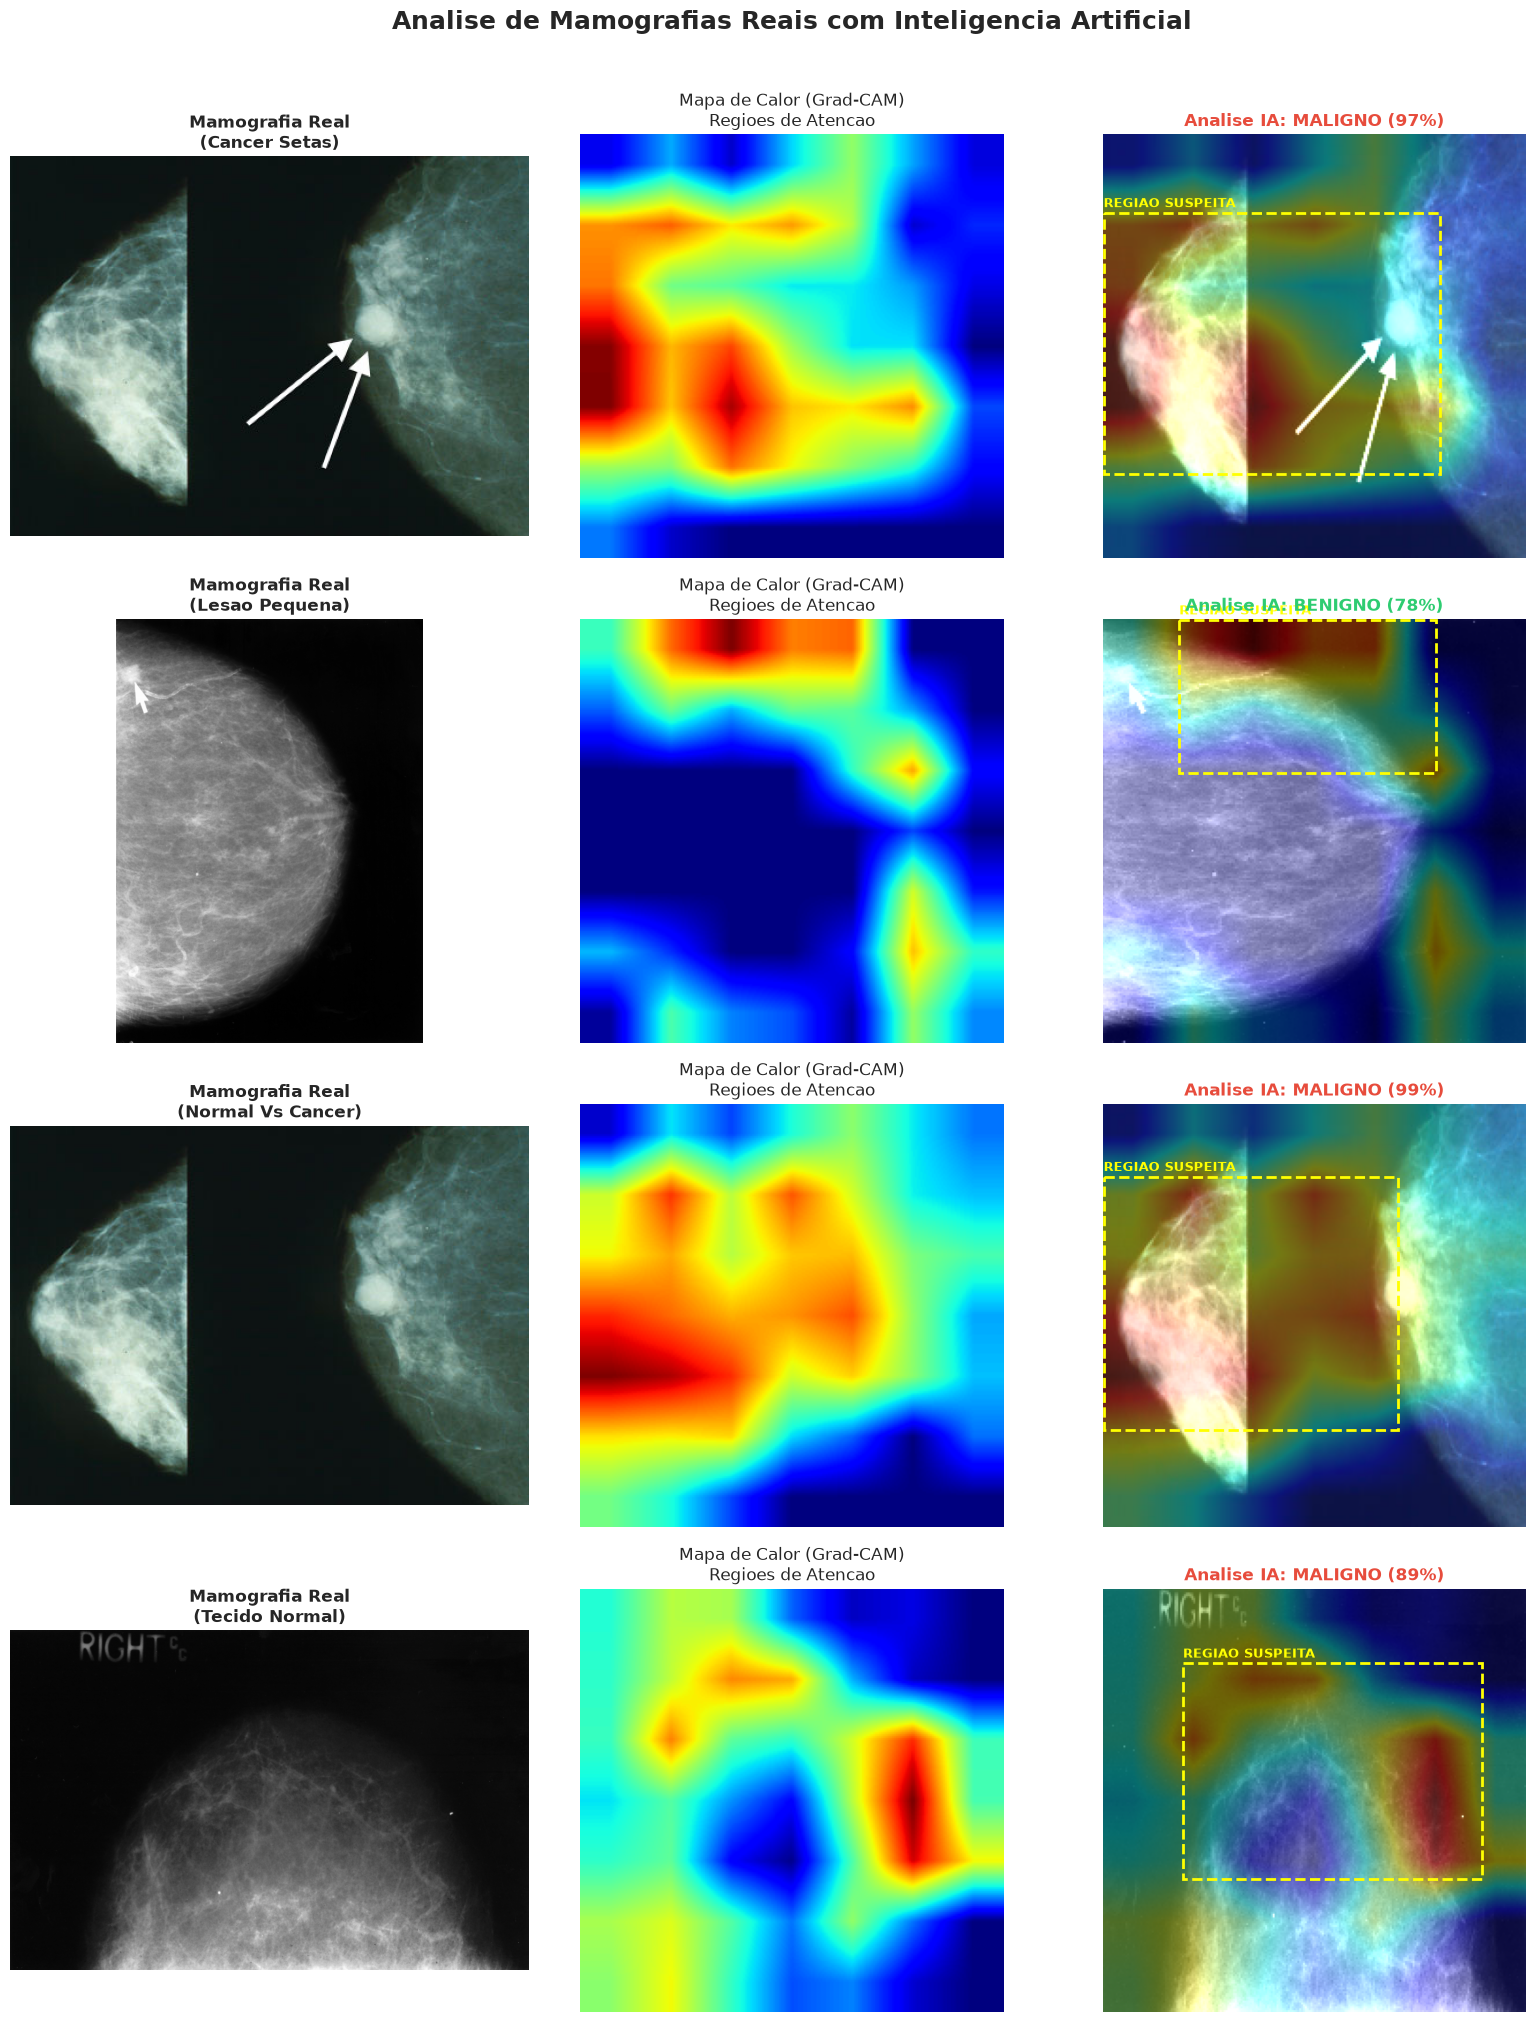

In [17]:
def gradcam(img_arr, modelo, layer="Conv_1"):
    lc = modelo.get_layer(layer)
    gm = tf.keras.models.Model(inputs=modelo.input, outputs=[lc.output, modelo.output])
    with tf.GradientTape() as t:
        co, pr = gm(img_arr)
        loss = pr[:, 0]
    g = t.gradient(loss, co)
    w = tf.reduce_mean(g, axis=(0, 1, 2))
    h = tf.squeeze(co[0] @ w[..., tf.newaxis])
    return (tf.maximum(h, 0) / (tf.math.reduce_max(h) + 1e-8)).numpy()


# Aplicação em mamografias reais (Wikimedia Commons / National Cancer Institute)
real_dir = "data/images/real_samples"
real_imgs = {}
if os.path.exists(real_dir):
    for f in sorted(os.listdir(real_dir)):
        if f.endswith((".jpg", ".png")):
            real_imgs[f] = cv2.imread(os.path.join(real_dir, f))

if real_imgs:
    n = len(real_imgs)
    fig, axes = plt.subplots(n, 3, figsize=(16, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    for idx, (nome, ibgr) in enumerate(real_imgs.items()):
        irgb = cv2.cvtColor(ibgr, cv2.COLOR_BGR2RGB)
        i224 = cv2.resize(irgb, (224, 224)).astype(np.float32) / 255.0
        batch = np.expand_dims(i224, 0)
        prob = model_cnn.predict(batch, verbose=0)[0][0]
        pred_lbl = "MALIGNO" if prob > 0.5 else "BENIGNO"
        conf = prob if prob > 0.5 else 1 - prob
        hm = gradcam(batch, model_cnn)
        hm_r = cv2.resize(hm, (224, 224))
        hm_c = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * hm_r), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(hm_c * 0.4 + i224, 0, 1)
        lbl = nome.replace("mamografia_", "").replace(".jpg", "").replace("_", " ").title()
        axes[idx, 0].imshow(irgb)
        axes[idx, 0].set_title(f"Mamografia Real\n({lbl})", fontsize=12, fontweight="bold")
        axes[idx, 0].axis("off")
        axes[idx, 1].imshow(hm_r, cmap="jet")
        axes[idx, 1].set_title("Mapa de Calor (Grad-CAM)\nRegioes de Atencao", fontsize=12)
        axes[idx, 1].axis("off")
        axes[idx, 2].imshow(overlay)
        mask = hm_r > 0.7
        coords = np.where(mask)
        if len(coords[0]) > 0:
            from matplotlib.patches import Rectangle

            axes[idx, 2].add_patch(
                Rectangle(
                    (coords[1].min(), coords[0].min()),
                    coords[1].max() - coords[1].min(),
                    coords[0].max() - coords[0].min(),
                    lw=2,
                    ec="yellow",
                    fc="none",
                    ls="--",
                )
            )
            axes[idx, 2].text(
                coords[1].min(), coords[0].min() - 3, "REGIAO SUSPEITA", color="yellow", fontsize=9, fontweight="bold"
            )
        cor = "#e74c3c" if pred_lbl == "MALIGNO" else "#2ecc71"
        axes[idx, 2].set_title(f"Análise IA: {pred_lbl} ({conf:.0%})", fontsize=12, fontweight="bold", color=cor)
        axes[idx, 2].axis("off")
    plt.suptitle("Análise de Mamografias Reais com Inteligencia Artificial", fontsize=18, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print(
        "Pasta data/images/real_samples não encontrada ou vazia. Adicione mamografias reais (.jpg/.png) para gerar a análise Grad-CAM."
    )

## 13. Conclusão Final

O desenvolvimento deste Tech Challenge comprovou a viabilidade técnica da classificação automatizada de tumores com foco em segurança diagnóstica. A metodologia adotada permitiu a construção de um pipeline que prioriza a Sensibilidade (Recall), consolidando o modelo como uma camada robusta de triagem para suporte à decisão clínica.

A integração da Análise de Componentes Principais (PCA) com a Regressão Logística entregou três pilares fundamentais:

**Eficiência Dimensional:** Redução da complexidade do espaço de características (de 30 para 10 componentes) mantendo 95% da variância explicada, o que otimiza o processamento sem perda de sinal preditivo.

**Segurança Clínica:** A manutenção de altos índices de Recall demonstra que o modelo é eficaz na detecção da classe maligna, mitigando falhas críticas (falsos negativos) que poderiam comprometer o tratamento do paciente.

**Auditabilidade e Interpretabilidade:** A escolha por um modelo linear pós-redução de dimensionalidade garante que o sistema seja computacionalmente leve e estatisticamente interpretável, facilitando a validação dos resultados por especialistas.

Em última análise, a solução proposta cumpre o objetivo de oferecer rapidez e segurança estatística, servindo como um suporte confiável na triagem de exames de câncer de mama e permitindo que o corpo médico foque nos casos de maior complexidade.